In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd 
import time

from scipy.ndimage import binary_dilation, binary_erosion
from skimage.morphology import opening, closing, area_closing, area_opening
from skimage.morphology import disk

from skimage.measure import label, regionprops, regionprops_table

In [2]:
def rgb2gray(rgb):

    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b   # calibrated for contemporary CRT phosphors

    return gray

# Extracting Objects and Features 

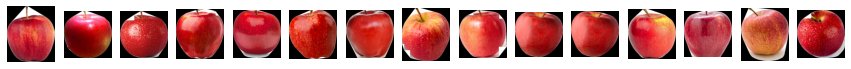

In [3]:
apples = Image.open('Inputs/apples5.png')
apples_array = np.array(apples)
apples_GS = np.array(apples.convert('L'))

threshold = 210
apples_segmented_binary =  np.invert(cv2.threshold(apples_GS, threshold, 255, cv2.THRESH_BINARY)[1])
# plt.imshow(apples_segmented_binary, cmap='gray')
strel = disk(8)
apples_closed = closing(apples_segmented_binary, footprint=strel)
# plt.imshow(apples_closed, cmap='gray')

label_apples = label(apples_closed) # label pixels based on connectivity. count starts at upper right region

properties = ['area','bbox_area', 'extent',  
              'mean_intensity', 'solidity', 'eccentricity', 
              'orientation']

apples_measurement_table = pd.DataFrame(regionprops_table(label_apples, apples_GS, 
             properties=properties))

apples_measurement_table
apples_regions = regionprops(label_apples)

masks = []
bbox = []
list_of_index = []
for num, x in enumerate(apples_regions):
    area = x.area   
    convex_area = x.convex_area
    if (area>100):    # filter out entries with area less than 6000, manually chosen
                                  # add more (and ____) to filter out more parameters
        masks.append(apples_regions[num].convex_image)
        bbox.append(apples_regions[num].bbox)   
        list_of_index.append(num)
apples_count = len(masks)


apples_good_measurements = apples_measurement_table.loc[list_of_index]  # regions that fit the area_threshold
apples_good_measurements

apples_avg_GS = []
fig, ax = plt.subplots(1, int(apples_count), figsize=(15,3))
for axis, box, mask in zip(ax.flatten(), bbox, masks):
    red  =  apples_array[:,:,0][box[0]:box[2], box[1]:box[3]] * mask
    green = apples_array[:,:,1][box[0]:box[2], box[1]:box[3]] * mask
    blue  = apples_array[:,:,2][box[0]:box[2], box[1]:box[3]] * mask
    apples_region_image = np.dstack([red,green,blue])
    
    # take average grayscale of each region
    apples_region_GS = rgb2gray(apples_region_image)
    apples_curr_avg_GS = np.mean(apples_region_image)
    apples_avg_GS.append(apples_curr_avg_GS)
    
    axis.imshow(apples_region_image)
    axis.axis('off')    # i can only display multiples of 2. In this case there are 15 objects but
                        # i could only show 14. Nevertheless, they are still accesible in good_measurements

# print(len(apples_avg_GS))  # average grayscale values

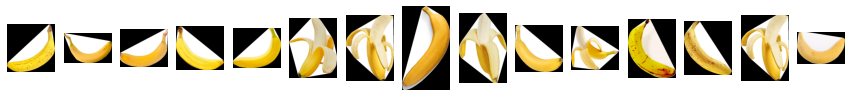

In [4]:
bananas = Image.open('Inputs/bananas2.png')
bananas_array = np.array(bananas)
bananas_GS = np.array(bananas.convert('L'))

threshold = 210
bananas_segmented_binary =  np.invert(cv2.threshold(bananas_GS, threshold, 255, cv2.THRESH_BINARY)[1])
# plt.imshow(bananas_segmented_binary, cmap='gray')
strel = disk(8)
bananas_closed = closing(bananas_segmented_binary, footprint=strel)
# plt.imshow(bananas_closed, cmap='gray')

label_bananas = label(bananas_closed) # label pixels based on connectivity. count starts at upper right region

properties = ['area','bbox_area', 'extent',  
              'mean_intensity', 'solidity', 'eccentricity', 
              'orientation']

bananas_measurement_table = pd.DataFrame(regionprops_table(label_bananas, bananas_GS, 
             properties=properties))

bananas_measurement_table
bananas_regions = regionprops(label_bananas)

masks = []
bbox = []
list_of_index = []
for num, x in enumerate(bananas_regions):
    area = x.area   
    convex_area = x.convex_area
    if (area>100):    # filter out entries with area less than 6000, manually chosen
                                  # add more (and ____) to filter out more parameters
        masks.append(bananas_regions[num].convex_image)
        bbox.append(bananas_regions[num].bbox)   
        list_of_index.append(num)
bananas_count = len(masks)
len(list_of_index)

bananas_good_measurements = bananas_measurement_table.loc[list_of_index]  # regions that fit the area_threshold
bananas_good_measurements

bananas_avg_GS = []
fig, ax = plt.subplots(1, int(bananas_count), figsize=(15,3))
for axis, box, mask in zip(ax.flatten(), bbox, masks):
    red  =  bananas_array[:,:,0][box[0]:box[2], box[1]:box[3]] * mask
    green = bananas_array[:,:,1][box[0]:box[2], box[1]:box[3]] * mask
    blue  = bananas_array[:,:,2][box[0]:box[2], box[1]:box[3]] * mask
    bananas_region_image = np.dstack([red,green,blue])
    
    bananas_region_GS = rgb2gray(bananas_region_image)      # get average grayscale
    bananas_curr_avg_GS = np.mean(bananas_region_image)
    bananas_avg_GS.append(bananas_curr_avg_GS)
    
    
    axis.imshow(bananas_region_image)
    axis.axis('off')    # i can only display multiples of 2. In this case there are 15 objects but
                        # i could only show 14. Nevertheless, they are still accesible in good_measurements
        


# Feature Space

In [5]:
eccentricity_apples = apples_good_measurements.eccentricity.values
eccentricity_bananas = bananas_good_measurements.eccentricity.values

# plt.title('Eccentricities')

# plt.plot(eccentricity_apples, color='r', label='apple')
# plt.plot(eccentricity_bananas, color='y', label='banana')
# plt.legend()

In [6]:
# plt.plot(bananas_avg_GS, color='y', label='banana')
# plt.plot(apples_avg_GS, color='r', label='apple')
# plt.title('Average GrayScale Values')
# plt.legend()

In [7]:
# fig, ax = plt.subplots(1,2)
# ax[0].imshow(apples_GS, cmap='gray')
# ax[1].imshow(bananas_GS, cmap='gray')

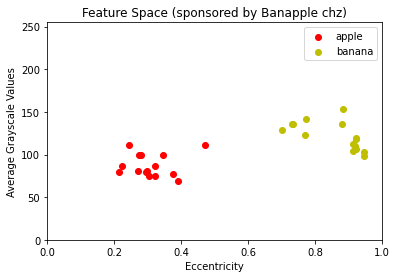

In [8]:
plt.scatter(eccentricity_apples, apples_avg_GS, color='r', label='apple')
plt.scatter(eccentricity_bananas, bananas_avg_GS, color='y', label='banana')
plt.xlabel('Eccentricity')
plt.ylabel('Average Grayscale Values')
plt.xlim(0,1)
plt.ylim(0,255)
plt.title('Feature Space (sponsored by Banapple chz)')
plt.legend()

# Perceptron (wowerz it sounds so sciency)

In [9]:
'''
Perceptron that classifies two classes based on two features 

Args: 
feature_matrix = N X 2 matrix of features, each row represents different objects while each column
                 represents a feature. Elememts must be normalized i.e. ranges from 0-1. There must
                 be a same number of objects per class, so the number of rows must be even.  Lastly,
                 the features of the same class must be in succeeding rows and not separated. 
                 
learning_rate = int, range from 0 to 1

constant_bias = int, padded on the beginning of feature vectors, default val is 1

epoch = int, iterations for training perceptron, default is 1000

'''


class Perceptron_2Class():
    
    def __init__(self, feature_matrix, learning_rate, constant_bias = 1, epochs = 100):
        self.raw_feature_matrix = feature_matrix
        self.features = np.insert(feature_matrix, 0, constant_bias, axis=1) # insert a 1 in the first column of each feature vector
        self.curr_weight = np.random.uniform(low=0, high=1, size = np.shape(self.features)[1])
        self.rows = np.shape(feature_matrix)[0]
        self.half_rows = self.rows // 2
        # Now we create a list with an element corresponding to each object/instance. The value is
        # -1 for objects in class 1 and +1 for objects in class 2. 
        self.class_labels = np.hstack((-np.ones(self.half_rows), np.ones(self.rows - self.half_rows)))
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.w0 = np.array([])
        self.w1 = np.array([])
        self.w2 = np.array([])
        
        
    def threshold (self, a):    # in this case it's a step function, used in perceptron algo later
        return 1 if a >= 0 else -1 
    
    
    def perceptron_algorithm(self, x_vec, w_vec):
        weighted_sum = np.matmul(np.transpose(x_vec), w_vec)  # spits out a (see manual)
        output = self.threshold(weighted_sum)                 # spits out z (see manual)
        return output     # perceptron score
    
    
    def weight_change(self):          # calculate weight change for all objects
        for index, x_vec in enumerate(self.features):   # iterate over all bananas or apples or whatever instance
            curr_perceptron = self.perceptron_algorithm(x_vec, self.curr_weight) # vals of +-1
            # Now apply weight change formula 
            delta_w = self.learning_rate * (self.class_labels[index] - curr_perceptron) * x_vec 
            self.curr_weight += delta_w
            self.w0, self.w1, self.w2 = np.append(self.w0, self.curr_weight[0]), np.append(self.w1, self.curr_weight[1]), np.append(self.w2, self.curr_weight[2])
            # final line is for the error plot
    
    
    def runner(self):                  # repeat weight change algorithm over number of epochs
        for i in range(self.epochs):
            self.weight_change()
            
            
    def decision_line(self, x):        # create function for decision line for plotting
        return (-self.curr_weight[1] / self.curr_weight[2])*x + (-self.curr_weight[0]/self.curr_weight[2])
    
    
    def feature_space_plot(self):   
        x = np.linspace(0, 1, 1000)
        f = self.decision_line(x)
        first_half = self.raw_feature_matrix[:self.raw_feature_matrix.shape[0] // 2]  # slice feature matrix, this is class 1
        second_half = self.raw_feature_matrix[self.raw_feature_matrix.shape[0] // 2:] # slice feature matrix, this is class 2
        
        # ======== You can modify labels and shit, just not variable names =================
        fig1, ax1 = plt.subplots(1)
        ax1.scatter(first_half[:,0], first_half[:,1], color='r', label='apple', s=3)
        ax1.scatter(second_half[:,0], second_half[:,1], color='y', label='banana', s=3)
        ax1.plot(x, f, label='Decision Line')
        ax1.set_xlabel('Eccentricity')
        ax1.set_ylabel('Mean Grayscale Values')
        ax1.set_xlim(0,1)
        ax1.set_ylim(0,1)
        ax1.set_title('Feature Space (Training Data)')
        ax1.legend()
        
        
    def error_plot(self):
        x = np.linspace(0,1, len(self.w0)-1)
        fig2, ax2 = plt.subplots(1)
        ax2.plot(x, np.diff(self.w0), label='Weight 0 Diff')   # plot current weight - prev weight
        ax2.plot(x, np.diff(self.w1), label='Weight 1 Diff')
        ax2.plot(x, np.diff(self.w2), label='Weight 2 Diff')
        ax2.legend()
        ax2.set_title("Error Plot")
        
    def test(self, x1, x2): # the inputs are features, float from 0-1
        score = self.curr_weight[0] + self.curr_weight[1]*x1 + self.curr_weight[2]*x2
#         state = ''
#         if score >= 0:
#             state = 'This object belongs to class 1 (Bananas) with a score of '
#         else:
#             state = 'This object belongs to class 2 (Apples) with a score of '
        
#         print(state)
        return score
            

In [10]:
'''
In this cell we create the feature matrix
'''

eccentricities = np.concatenate((eccentricity_apples, eccentricity_bananas)) 
mean_grayscales = np.concatenate((apples_avg_GS, bananas_avg_GS))  / 255      # we normalize

feature_matrix = np.column_stack((eccentricities, mean_grayscales))
learning_rate = 0.001

# print(feature_matrix)


In [11]:
'''
Now let's train the perceptron!!!
'''
start_time = time.time()
# too many epochs and you will overshoot
perceptron = Perceptron_2Class(feature_matrix, learning_rate, epochs=1000) 
perceptron.runner()



print("--- %s seconds ---" % (time.time() - start_time))

--- 1.0623583793640137 seconds ---


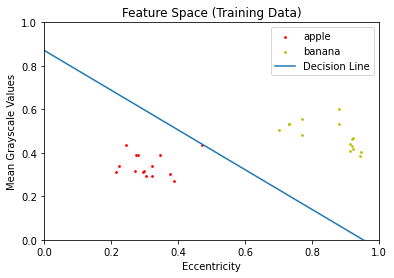

In [12]:
perceptron.feature_space_plot()
# perceptron.error_plot()

In [13]:
perceptron.test(0.2, 0.2)

-0.2746033287821893

# Test

In [14]:
test_avg_GS = [] 
test_eccentricities = []

for i in range(10):  # i have images stored as 0.jpg etc in the Test_Images folder
    test = Image.open('Test_Images/' + str(i) +'.jpg')
    test_array = np.array(test)
    test_GS = np.array(test.convert('L'))

    # ===================== GET REGIONS ===============================
    threshold = 180
    test_segmented_binary =  np.invert(cv2.threshold(test_GS, threshold, 255, cv2.THRESH_BINARY)[1])
    # plt.imshow(test_segmented_binary,cmap='gray')

    label_test = label(test_segmented_binary)
    properties = ['area','bbox_area', 'eccentricity']

    test_measurement_table = pd.DataFrame(regionprops_table(label_test, test_GS, 
                 properties=properties))

    # test_measurement_table     # i just wanted to print it
    test_regions = regionprops(label_test)    # make the regions into objects

    test_curr_eccentricity = test_measurement_table.eccentricity.values  # eccentricity of current image

    # ========================= FILTER OUT REGIONS W/ V SMALL AREAS ==================================

    list_of_index = []
    # print(len(test_regions))
    for num, x in enumerate(test_regions):
        area = x.area   
        convex_area = x.convex_area

        if (area>100):    # filter out entries with area less than 6000, manually chosen
                          # add more (and ____ ) to filter out more parameters
            mask = test_regions[num].convex_image    # cropped regions of segmented object
            bbox = test_regions[num].bbox            # BOUNDING BOX
            list_of_index.append(num)
    test_count = len(masks)

    # ============================ GET VALID ECCENTRICITIES ==========================
    test_good_measurements = test_measurement_table.loc[list_of_index]  # measurements that fit the area_threshold

    test_curr_eccentricity = test_good_measurements.eccentricity.values
    test_eccentricities.append(test_curr_eccentricity)

    # ======================== GET MEAN GRAYSCALE =============================

    red  =  test_array[:,:,0][bbox[0]:bbox[2], bbox[1]:bbox[3]] * mask
    green = test_array[:,:,1][bbox[0]:bbox[2], bbox[1]:bbox[3]] * mask
    blue  = test_array[:,:,2][bbox[0]:bbox[2], bbox[1]:bbox[3]] * mask
    test_region_image = np.dstack([red,green,blue])
    plt.imsave('Test_Regions/'+str(i)+'.jpg', test_region_image)
    test_region_GS = rgb2gray(test_region_image)
    test_curr_avg_GS = np.mean(test_region_image) /  255    # normalize
    test_avg_GS.append(test_curr_avg_GS)


# TODO: ADD THIS WHOLE BLOCK TO A FOR LOOP THAT WILL ITERATE THRU ALL IMAGES
# print(test_avg_GS, test_eccentricities)

In [15]:
text = ''' Lettuce now test the perceptron by iterating thru all the collected features pairwise. 
'''
states = [] # classifications of images

for ecc, GS in zip(test_eccentricities, test_avg_GS): # loop pairwise thru all elements
    print(ecc,GS)
    state = 0
    curr_classification = perceptron.test(ecc,GS)     # test the perceptron,tis defined in the class above
#     print(curr_classification)
    if curr_classification >= 0: 
        state = 0  # Banana
    else: 
        state = 1  # Apple
        
    states.append(state) 

[0.50205976] 0.309517723952326
[0.36785476] 0.2664406681190995
[0.47377921] 0.2818520886615516
[0.51832783] 0.29504197530864196
[0.32494333] 0.30699346405228756
[0.83509202] 0.348860294117647
[0.88300999] 0.31837321595304785
[0.93033511] 0.45437171717171715
[0.97327263] 0.4016440879382056
[0.97014657] 0.31878746901059274


In [16]:
print(states)

[1, 1, 1, 1, 1, 0, 0, 0, 0, 0]


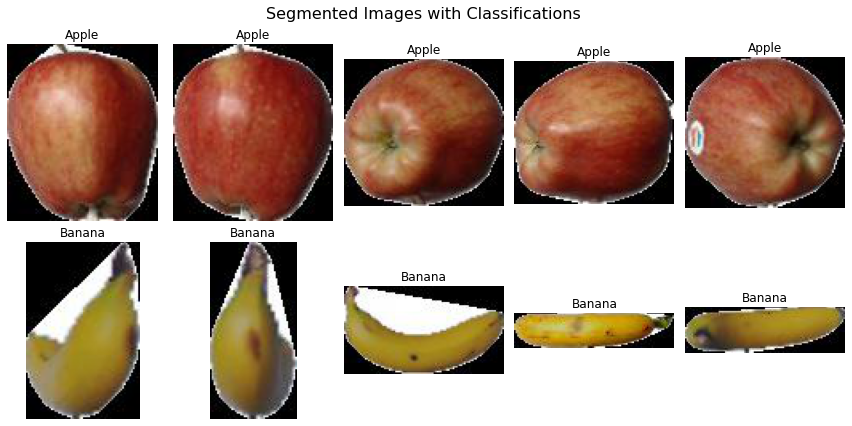

In [17]:
fig, axs = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Segmented Images with Classifications', fontsize=16)
for i in range(10):
    # Load segmented image
    image_path = 'Test_Regions/'+str(i)+'.jpg'
    image = plt.imread(image_path)

    # Get the classification for the current image
    classification = "Banana" if states[i] == 0 else "Apple"

    # Determine the subplot position
    row = i // 5
    col = i % 5

    # Plot the image and set the title with the classification
    axs[row, col].imshow(image)
    axs[row, col].set_title(classification)
    axs[row, col].axis('off')

plt.tight_layout()
plt.show()   # this code block  is from chatgpt, i figured it's fine cuz it's just 
             # for the figure so i figured yea it's fine, go figure